# Rough neuropil-subdomain analysis for the SECOND AD-WT MERSCOPE pair

Pipeline (mirrors `code/benchmark/benchmark_subtyping.ipynb` + `code/7_neuropil_subdomains.ipynb`, but self-contained and only using the rough granule adata for the second sample pair):

1. Concatenate the two granule adata (`output/MERSCOPE_AD_2` and `output/MERSCOPE_WT_2`). Coordinates are **not** aligned across samples; each sample keeps its own coordinate frame and is gridded independently so granules from the two samples are never mixed in a spot.
2. Manual granule subtyping (k-means on marker genes → heatmap → manual cluster→subtype mapping). Only the manual route is implemented; `MANUAL_SUBTYPE_MAPPING` is a **placeholder** to be filled after inspecting `heatmap_subtype.jpeg`.
3. Build four cortical (Isocortex) neuropil subdomains from the granule-subtype composition of 50x50 um spots (`spot_embedding` on `granule_subtype_kmeans` → row-normalize → KMeans, k=4).
4. Deliverable: for each neuropil subdomain, differentially expressed genes (DEGs) of the spot-level **granule** expression comparing AD vs WT (Wilcoxon).

Enrichment analysis is intentionally left out (see note in step 4).

Use the `mcDETECT-env` kernel.

In [1]:
import os
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.sparse import csr_matrix, issparse
from sklearn.cluster import KMeans, MiniBatchKMeans

from mcDETECT.downstream import spot_embedding

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

## Config

In [2]:
# Repo root (this notebook lives in code/)
BASE = os.path.abspath("..")

AD_PATH = os.path.join(BASE, "output/MERSCOPE_AD_2/granule_adata_raw.h5ad")
WT_PATH = os.path.join(BASE, "output/MERSCOPE_WT_2/granule_adata_raw.h5ad")

ROI = "Isocortex"          # cortical neuropil subdomains are built within the isocortex
GRID_LEN = 50              # spot size in microns (50 x 50)
N_CLUSTERS = 15            # k-means clusters for manual subtyping (as in benchmark_subtyping)
N_SUBDOMAINS = 4           # four cortical neuropil subdomains
SEED = 42

# k-means clusters that do not correspond to any granule subtype and are dropped from ALL
# downstream analysis (subtyping annotation, subdomain construction, DEGs).
DROP_CLUSTERS = ["9"]

OUTPUT_PATH = os.path.join(BASE, f"output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_{ROI}_{GRID_LEN}/")
os.makedirs(OUTPUT_PATH, exist_ok=True)
print(OUTPUT_PATH)

/Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_Isocortex_50/


In [3]:
# Marker genes (from benchmark_subtyping.ipynb). Used for k-means subtyping + heatmap.
marker_genes = {
    "pre-syn": ["Bsn", "Gap43", "Nrxn1", "Slc17a6", "Slc17a7", "Slc32a1", "Snap25", "Stx1a", "Syn1", "Syp", "Syt1", "Vamp2", "Cplx2"],
    "post-syn": ["Camk2a", "Dlg3", "Dlg4", "Gphn", "Gria1", "Gria2", "Homer1", "Homer2", "Nlgn1", "Nlgn2", "Nlgn3", "Shank1", "Shank3"],
    "axons": ["Ank3", "Nav1", "Sptnb4", "Nfasc", "Mapt", "Tubb3"],
    "dendrites": ["Actb", "Cyfip2", "Ddn", "Dlg4", "Map1a", "Map2"],
}
ref_genes = ["Bsn", "Gap43", "Nrxn1", "Slc17a6", "Slc17a7", "Slc32a1", "Stx1a", "Syn1", "Syp", "Syt1", "Vamp2", "Cplx2",
             "Camk2a", "Dlg3", "Dlg4", "Gphn", "Gria1", "Gria2", "Homer1", "Homer2", "Nlgn1", "Nlgn2", "Nlgn3", "Shank1", "Shank3",
             "Cyfip2", "Ddn", "Map1a", "Map2", "Ank3", "Nav1", "Nfasc", "Mapt", "Tubb3"]

### PLACEHOLDER: manual cluster → subtype mapping

After running the subtyping cell once, open `OUTPUT_PATH/heatmap_subtype.jpeg`, read off which of the `N_CLUSTERS` k-means clusters (labelled `"0"`..`"14"`) look pre-syn / post-syn / dendrites / axons / mixed, and fill in the lists below. Combination keys with `" & "` are treated as `"mixed"` in `*_manual_simple`. Clusters left unlisted stay unannotated.

This mapping only drives the manual-subtype annotation + heatmap coloring; the subdomain construction and the AD-vs-WT DEG deliverable do **not** depend on it, so the notebook runs end-to-end even while the mapping is still empty.

In [4]:
MANUAL_SUBTYPE_MAPPING = {
    "pre-syn": ["1", "2", "3", "4", "7", "8"],          # e.g. ["0", "11", "12"]
    "post-syn": ["0", "5"],         # e.g. ["1", "2", "3"]
    "dendrites": ["6", "13"],        # e.g. ["4", "8"]
    "axons": [],
    "pre & post": [],
    "pre & den": [],
    "post & den": ["11", "14"],
    "pre & post & den": ["10", "12"],
    "others": [],
}

## Helper functions

In [5]:
def apply_manual_annotation(granule, mapping, cluster_col="granule_subtype_kmeans"):
    """Map k-means cluster ids -> manual subtype (fine) + _simple (mixed for combinations)."""
    k2sub = {}
    for subtype, clusters in mapping.items():
        for c in clusters:
            k2sub[str(c)] = subtype
    fine = granule.obs[cluster_col].astype(str).map(k2sub)
    granule.obs["granule_subtype_manual"] = fine
    granule.obs["granule_subtype_manual_simple"] = fine.apply(
        lambda s: "mixed" if (pd.notna(s) and " & " in str(s)) else (str(s) if pd.notna(s) else np.nan)
    )
    return granule


def cluster_to_simple_category(mapping):
    """cluster id (str) -> simple subtype category (for heatmap column coloring)."""
    c2cat = {}
    for subtype, clusters in mapping.items():
        simple = "mixed" if (pd.notna(subtype) and " & " in str(subtype)) else str(subtype)
        for c in clusters:
            c2cat[str(c)] = simple
    return c2cat


def build_spot_grid(obs, grid_len, x_col="global_x", y_col="global_y"):
    """Occupied-cell grid: one spot per 50x50 tile that contains >=1 granule.

    Centroid of tile (ix, iy) is ((ix+0.5)*grid_len, (iy+0.5)*grid_len), so spot_embedding's
    half-open box [cx-h, cx+h) exactly matches the tile [ix*grid_len, (ix+1)*grid_len).
    """
    gx = obs[x_col].to_numpy(dtype=float)
    gy = obs[y_col].to_numpy(dtype=float)
    ix = np.floor(gx / grid_len).astype(int)
    iy = np.floor(gy / grid_len).astype(int)
    cells = np.unique(np.stack([ix, iy], axis=1), axis=0)
    cx = (cells[:, 0] + 0.5) * grid_len
    cy = (cells[:, 1] + 0.5) * grid_len
    spots = anndata.AnnData(X=np.zeros((len(cx), 1), dtype=np.float32))
    spots.obs["global_x"] = cx
    spots.obs["global_y"] = cy
    spots.obs["spot_id"] = [f"spot_{i}" for i in range(len(cx))]
    return spots


def styled_scatter(obs_df, color_series, path, title=""):
    """Simple spatial scatter of spots colored by a categorical/continuous series."""
    fig, ax = plt.subplots(figsize=(8, 8))
    if color_series.dtype.name in ("category", "object"):
        cats = pd.Categorical(color_series)
        palette = sns.color_palette("Set2", n_colors=len(cats.categories))
        for cat, col in zip(cats.categories, palette):
            m = color_series == cat
            ax.scatter(obs_df.loc[m, "global_x"], obs_df.loc[m, "global_y"], s=6, color=col, label=str(cat))
        ax.legend(markerscale=2, frameon=False, fontsize=8)
    else:
        sca = ax.scatter(obs_df["global_x"], obs_df["global_y"], s=6, c=color_series, cmap="Reds")
        fig.colorbar(sca, ax=ax, shrink=0.6)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

## 1. Load and concatenate the two granule adata

In [6]:
ad = sc.read_h5ad(AD_PATH)
wt = sc.read_h5ad(WT_PATH)
ad.obs["batch"] = "MERSCOPE_AD_2"
ad.obs["sample"] = "AD"
wt.obs["batch"] = "MERSCOPE_WT_2"
wt.obs["sample"] = "WT"

# Same 290-gene panel; concat on shared genes. index_unique avoids obs_name collisions.
granule = anndata.concat([wt, ad], join="inner", index_unique="-")
granule.obs["sample"] = granule.obs["sample"].astype(str)
granule.obs["batch"] = granule.obs["batch"].astype(str)

# Preserve raw counts for spot-level expression aggregation.
granule.layers["counts"] = csr_matrix(granule.X.copy())
print(f"Concatenated granule adata: {granule.shape}")
print(granule.obs["sample"].value_counts())

Concatenated granule adata: (1509233, 290)
sample
WT    755240
AD    753993
Name: count, dtype: int64


## 2. Manual granule subtyping (k-means → heatmap → map)

In [7]:
ref_genes_present = [g for g in ref_genes if g in granule.var_names]
sub = granule[:, ref_genes_present].copy()
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

X_sub = sub.X.toarray() if issparse(sub.X) else np.asarray(sub.X)
np.random.seed(SEED)
km = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=5000, random_state=SEED, n_init=20)
km.fit(X_sub)
labels = km.labels_.astype(str)
cats = [str(i) for i in range(N_CLUSTERS)]
granule.obs["granule_subtype_kmeans"] = pd.Categorical(labels, categories=cats, ordered=True)
sub.obs["granule_subtype_kmeans"] = granule.obs["granule_subtype_kmeans"].values
print(granule.obs["granule_subtype_kmeans"].value_counts().sort_index())

granule_subtype_kmeans
0     242602
1     108364
2      86757
3      42146
4      52624
5      80554
6     134278
7      67089
8      81714
9     216015
10     65325
11    142304
12     49238
13     88295
14     51928
Name: count, dtype: int64


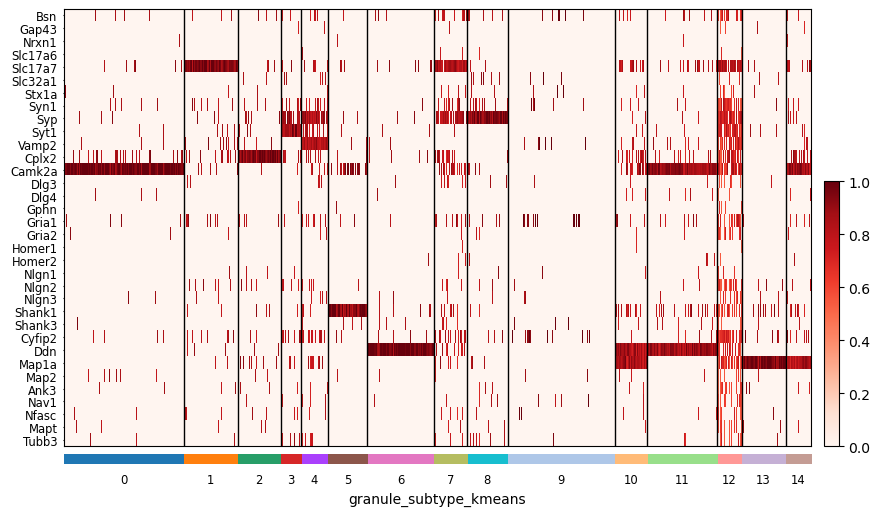

Saved heatmap_subtype.jpeg to /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_Isocortex_50/


In [8]:
# Heatmap of marker expression per k-means cluster (use to fill MANUAL_SUBTYPE_MAPPING).
sc.pl.heatmap(sub, var_names=ref_genes_present, groupby="granule_subtype_kmeans",
              cmap="Reds", standard_scale="var", dendrogram=False, swap_axes=True,
              show=False, figsize=(10, 6))
plt.gcf().savefig(os.path.join(OUTPUT_PATH, "heatmap_subtype.jpeg"), dpi=500, bbox_inches="tight")
plt.show()
print(f"Saved heatmap_subtype.jpeg to {OUTPUT_PATH}")

In [9]:
# Apply the (placeholder) manual mapping. Re-run this after editing MANUAL_SUBTYPE_MAPPING above.
granule = apply_manual_annotation(granule, MANUAL_SUBTYPE_MAPPING)
n_annot = granule.obs["granule_subtype_manual"].notna().sum()
print(f"Granules with a manual subtype assigned: {n_annot} / {granule.n_obs} "
      f"(0 is expected until MANUAL_SUBTYPE_MAPPING is filled in)")

Granules with a manual subtype assigned: 1293218 / 1509233 (0 is expected until MANUAL_SUBTYPE_MAPPING is filled in)


In [10]:
# Drop clusters that do not correspond to any subtype (identified from heatmap_subtype.jpeg).
# Removed from ALL downstream analysis: subdomain construction and AD-vs-WT DEGs.
if DROP_CLUSTERS:
    before = granule.n_obs
    granule = granule[~granule.obs["granule_subtype_kmeans"].isin(DROP_CLUSTERS)].copy()
    granule.obs["granule_subtype_kmeans"] = granule.obs["granule_subtype_kmeans"].cat.remove_unused_categories()
    print(f"Dropped clusters {DROP_CLUSTERS}: {before} -> {granule.n_obs} granules")
    print("Remaining clusters:", list(granule.obs["granule_subtype_kmeans"].cat.categories))

Dropped clusters ['9']: 1509233 -> 1293218 granules
Remaining clusters: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '10', '11', '12', '13', '14']


## 3. Build cortical neuropil subdomains from subtype composition

Each sample is gridded in its own coordinate frame (coordinates are not aligned), then the per-sample spot embeddings are stacked and clustered together into `N_SUBDOMAINS`.

In [11]:
granule_roi = granule[granule.obs["brain_area"] == ROI].copy()
print(f"{ROI} granules: {granule_roi.n_obs}")

# Composition features = remaining k-means clusters (dropped clusters already removed).
subtype_names = list(granule.obs["granule_subtype_kmeans"].cat.categories)
smoothing_radius = np.sqrt(2) * GRID_LEN + 1

emb_list, expr_list, obs_list = [], [], []
for s in ["WT", "AD"]:
    g_s = granule_roi[granule_roi.obs["sample"] == s].copy()
    spots_s = build_spot_grid(g_s.obs, GRID_LEN)
    print(f"  [{s}] granules={g_s.n_obs}, spots={spots_s.n_obs}")

    emb, _, aux, spot_granule_expr, _ = spot_embedding(
        spots=spots_s,
        granule_adata=g_s,
        adata=None,
        count_matrix=None,
        spot_loc_key=("global_x", "global_y"),
        spot_width=GRID_LEN,
        spot_height=GRID_LEN,
        granule_loc_key=("global_x", "global_y"),
        granule_subtype_key="granule_subtype_kmeans",
        subtype_names=subtype_names,
        granule_count_layer="counts",
        include_soma_features=False,
        smoothing=True,
        smoothing_radius=smoothing_radius,
        smoothing_mode="gaussian",
    )

    keep = aux["granule_count"] > 0
    obs_s = spots_s.obs.loc[keep].copy()
    obs_s["sample"] = s
    obs_s["batch"] = "MERSCOPE_AD_2" if s == "AD" else "MERSCOPE_WT_2"
    obs_s["granule_count"] = aux["granule_count"][keep]

    emb_list.append(emb[keep])
    expr_list.append(spot_granule_expr[keep])
    obs_list.append(obs_s)

embeddings = np.vstack(emb_list)
spot_granule_expression = np.vstack(expr_list)
spot_obs = pd.concat(obs_list, ignore_index=True)
print(f"Total spots with granules: {spot_obs.shape[0]}")

Isocortex granules: 324712
  [WT] granules=167133, spots=2142
  [AD] granules=157579, spots=2067
Total spots with granules: 4209


In [12]:
# Row-normalize the subtype composition, then cluster into N_SUBDOMAINS.
row_sums = embeddings.sum(axis=1, keepdims=True)
X_prop = np.divide(embeddings, row_sums, out=np.zeros_like(embeddings, dtype=float), where=row_sums > 0)

kmeans = KMeans(n_clusters=N_SUBDOMAINS, random_state=SEED, n_init=20)
sd_labels = kmeans.fit_predict(X_prop)
spot_obs["subdomain"] = pd.Categorical([f"Subdomain {l + 1}" for l in sd_labels],
                                       categories=[f"Subdomain {i + 1}" for i in range(N_SUBDOMAINS)],
                                       ordered=True)
print(spot_obs.groupby(["subdomain", "sample"]).size().unstack(fill_value=0))

spot_obs.to_parquet(os.path.join(OUTPUT_PATH, "spot_subdomain_labels.parquet"), index=False)

sample         AD   WT
subdomain             
Subdomain 1  1062   58
Subdomain 2   562  690
Subdomain 3   401  733
Subdomain 4    42  661


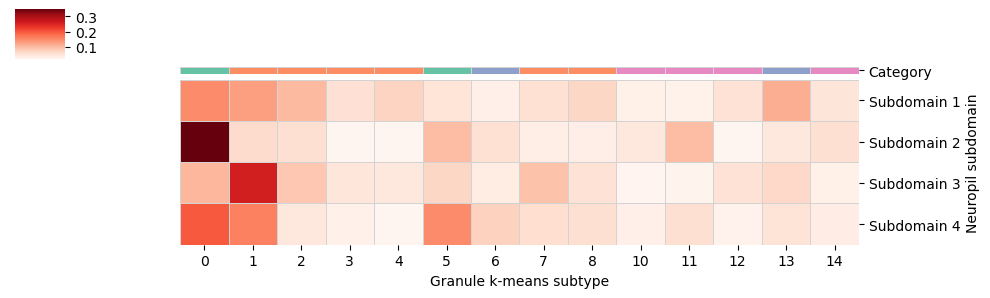

In [13]:
# Composition heatmap: mean subtype proportion per subdomain, columns colored by manual category.
comp_df = pd.DataFrame(X_prop, columns=subtype_names)
comp_df["subdomain"] = spot_obs["subdomain"].values
subdomain_means = comp_df.groupby("subdomain").mean().loc[[f"Subdomain {i + 1}" for i in range(N_SUBDOMAINS)]]

c2cat = cluster_to_simple_category(MANUAL_SUBTYPE_MAPPING)
col_cats = pd.Series([c2cat.get(s, "unannotated") for s in subtype_names], index=subtype_names, name="Category")
unique_cats = list(pd.unique(col_cats))
cat_palette = dict(zip(unique_cats, sns.color_palette("Set2", n_colors=len(unique_cats))))
col_colors = col_cats.map(cat_palette)

g = sns.clustermap(subdomain_means, cmap="Reds", col_colors=col_colors, row_cluster=False,
                   col_cluster=False, linewidths=0.5, linecolor="lightgray",
                   xticklabels=True, yticklabels=True, figsize=(10, 2.8))
g.ax_heatmap.set_xlabel("Granule k-means subtype")
g.ax_heatmap.set_ylabel("Neuropil subdomain")
g.savefig(os.path.join(OUTPUT_PATH, "heatmap_subdomain_composition.jpeg"), dpi=500, bbox_inches="tight")
plt.show()

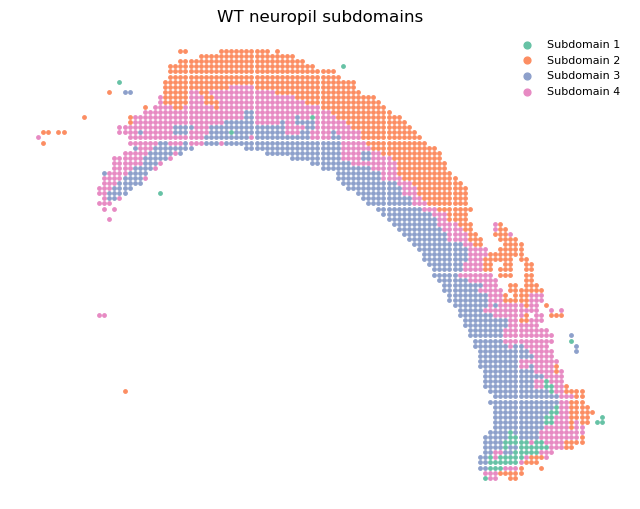

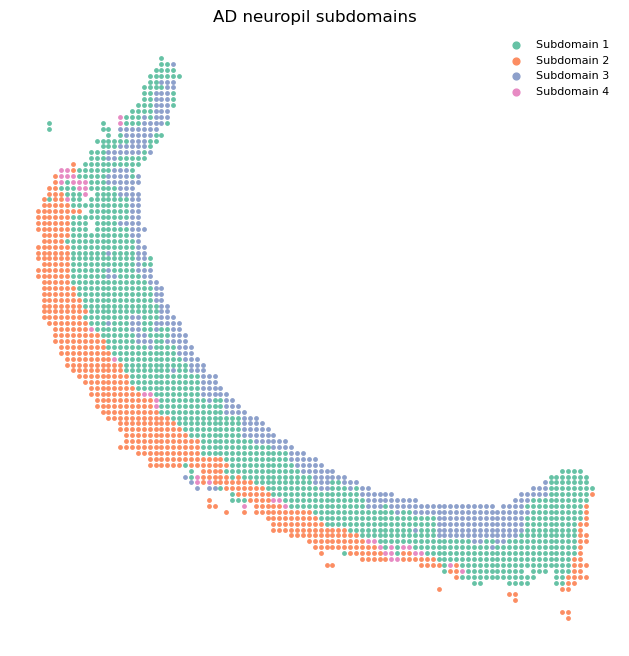

In [14]:
# Spatial scatter of subdomains, per sample (separate coordinate frames).
for s in ["WT", "AD"]:
    m = spot_obs["sample"] == s
    styled_scatter(spot_obs.loc[m], spot_obs.loc[m, "subdomain"],
                   os.path.join(OUTPUT_PATH, f"subdomains_{s}.jpeg"), title=f"{s} neuropil subdomains")

## 4. Deliverable: AD-vs-WT granule DEGs within each neuropil subdomain

**Note:** pathway/enrichment analysis is intentionally omitted; this produces the ranked DEG tables only. Run enrichment downstream on these gene lists if needed.

In [15]:
all_deg = []
for sd in [f"Subdomain {i + 1}" for i in range(N_SUBDOMAINS)]:
    m = (spot_obs["subdomain"] == sd).to_numpy()
    obs_sd = spot_obs.loc[m].copy()
    n_ad = int((obs_sd["sample"] == "AD").sum())
    n_wt = int((obs_sd["sample"] == "WT").sum())
    print(f"  {sd}: AD spots={n_ad}, WT spots={n_wt}")
    if n_ad < 2 or n_wt < 2:
        print(f"    Skipping {sd}: not enough spots in one condition.")
        continue

    expr_sd = spot_granule_expression[m].copy()
    de_adata = anndata.AnnData(X=expr_sd, obs=obs_sd.reset_index(drop=True), var=granule.var.copy())
    de_adata.var_names = granule.var_names
    sc.pp.normalize_total(de_adata, target_sum=1e4)
    sc.pp.log1p(de_adata)

    sc.tl.rank_genes_groups(de_adata, groupby="sample", groups=["AD"], reference="WT", method="wilcoxon")
    df = sc.get.rank_genes_groups_df(de_adata, group="AD")
    df = df.sort_values("logfoldchanges", ascending=False)
    df["subdomain"] = sd
    df["n_spots_AD"] = n_ad
    df["n_spots_WT"] = n_wt

    safe_sd = sd.replace(" ", "_")
    out_csv = os.path.join(OUTPUT_PATH, f"granule_DE_genes_AD_vs_WT_{safe_sd}.csv")
    df.to_csv(out_csv, index=False)
    print(f"    Saved {out_csv} ({df.shape[0]} genes)")
    all_deg.append(df)

  Subdomain 1: AD spots=1062, WT spots=58
    Saved /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_Isocortex_50/granule_DE_genes_AD_vs_WT_Subdomain_1.csv (290 genes)
  Subdomain 2: AD spots=562, WT spots=690
    Saved /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_Isocortex_50/granule_DE_genes_AD_vs_WT_Subdomain_2.csv (290 genes)
  Subdomain 3: AD spots=401, WT spots=733
    Saved /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_Isocortex_50/granule_DE_genes_AD_vs_WT_Subdomain_3.csv (290 genes)
  Subdomain 4: AD spots=42, WT spots=661
    Saved /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_Isocortex_50/granule_DE_genes_AD_vs_WT_Subdomain_4.csv (290 genes)


In [16]:
if all_deg:
    combined = pd.concat(all_deg, ignore_index=True)
    combined.to_csv(os.path.join(OUTPUT_PATH, "granule_DE_genes_AD_vs_WT_all_subdomains.csv"), index=False)
    print(f"Saved combined DEG table to {OUTPUT_PATH}granule_DE_genes_AD_vs_WT_all_subdomains.csv")
    display(combined.groupby("subdomain").head(5))

Saved combined DEG table to /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/neuropil_subdomains_Isocortex_50/granule_DE_genes_AD_vs_WT_all_subdomains.csv


,names,scores,logfoldchanges,pvals,pvals_adj,subdomain,n_spots_AD,n_spots_WT
0,Ndst3,2.865220,29.498131,4.167202e-03,1.272093e-02,Subdomain 1,1062,58
1,B2m,0.991342,27.593084,3.215187e-01,4.036382e-01,Subdomain 1,1062,58
2,Cplx3,0.882536,27.428307,3.774870e-01,4.583116e-01,Subdomain 1,1062,58
3,Vcan,0.640745,26.883520,5.216882e-01,5.898987e-01,Subdomain 1,1062,58
4,Nts,0.592387,26.785992,5.535914e-01,6.151015e-01,Subdomain 1,1062,58
290,Col6a1,2.658398,2.289610,7.851303e-03,2.014936e-02,Subdomain 2,562,690
291,Abca7,4.041187,2.202827,5.318140e-05,2.142029e-04,Subdomain 2,562,690
292,Csmd1,10.107446,2.174989,5.120186e-24,5.710977e-23,Subdomain 2,562,690
293,Prox1,2.575186,1.992610,1.001862e-02,2.441513e-02,Subdomain 2,562,690
294,Garnl3,7.066930,1.799458,1.583989e-12,1.312448e-11,Subdomain 2,562,690
